## Dawn Andrei Pamesa
## TS31

Imports

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Loading the Dataset

In [19]:
df = pd.read_csv("real_estate_taiwan-2.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


Select Features

In [20]:
X = df[["X2 house age", "X3 distance to the nearest MRT station"]]
y = df["Y house price of unit area"]

Check Missing Features

In [21]:
print(df.isnull().sum())
display(df[df.isnull().any(axis=1)])

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area


Imputing and Scaling

In [22]:
X = X.fillna(X.mean())

In [23]:
for column in X.select_dtypes(include=["object", "category"]).columns:
    X[column] = X[column].fillna(X[column].mode()[0])

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Splitting the Data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 310
Testing rows: 104


Plotting of Correlations

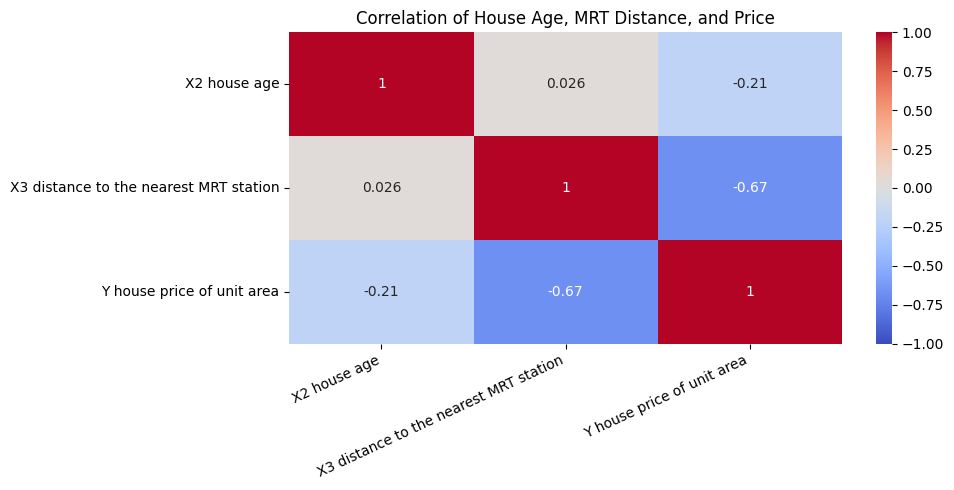

In [26]:
plt.figure(figsize=(10, 5))
sns.heatmap(selected_data.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of House Age, MRT Distance, and Price")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Training Multiple Linear Regression Model

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

Predicting and Reporting R²

In [28]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

print("Training R²:", round(r2_score(y_train, y_pred_train), 4))
print("Testing R²:", round(r2_score(y_test, y_pred_test), 4))

Training R²: 0.4841
Testing R²: 0.4879


Predicting using New Data

In [29]:
new_data = pd.DataFrame({
    "X2 house age": [20],
    "X3 distance to the nearest MRT station": [500]
})

new_data_scaled = scaler.transform(new_data)
new_pred = lr.predict(new_data_scaled)

print("Predicted house price per unit area:", round(new_pred[0], 2))

Predicted house price per unit area: 42.2


Summary

In [32]:
print("\nSummary")
print("Training R²:", r2_score(y_train, y_pred_train))
print("Testing R²:", r2_score(y_test, y_pred_test))
print("New prediction:", new_pred[0])

print("\nR² shows how much of the variation in house price the two features explain.")
print("The training and testing R² values are close, so the model performs similarly on both sets.")
print("The new prediction is the estimated price per unit area for a 20-year-old house 500 meters from the nearest MRT station.")


Summary
Training R²: 0.48409388284425114
Testing R²: 0.4879266843011125
New prediction: 42.19735909430818

R² shows how much of the variation in house price the two features explain.
The training and testing R² values are close, so the model performs similarly on both sets.
The new prediction is the estimated price per unit area for a 20-year-old house 500 meters from the nearest MRT station.
